In [41]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import gzip
import math
import pickle
import torch

In [42]:
def get_MNIST_data():
    with gzip.open("Proyecto1/Datasets/mnist.pkl.gz", 'rb') as f:
        train_set, valid_set, test_set = pickle.load(f, encoding='latin1')
    train_x, train_y = train_set
    valid_x, valid_y = valid_set

    train_x = np.vstack((train_x, valid_x))
    train_y = np.append(train_y, valid_y)

    test_x, test_y = test_set

    return train_x, train_y, test_x, test_y

In [33]:
def plot_images(X):
    if X.ndim == 1:
        X = np.array([X])
    num_images = X.shape[0]
    num_rows = math.floor(math.sqrt(num_images))
    num_cols = math.ceil(num_images/num_rows)
    for i in range(num_images):
        reshaped_image = X[i,:].reshape(28,28)
        plt.subplot(num_rows, num_cols, i+1)
        plt.imshow(reshaped_image, cmap = cm.Greys_r)
        plt.axis('off')
    plt.show()

(60000, 784)
(10000, 784)


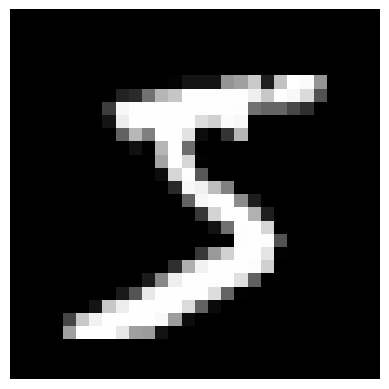

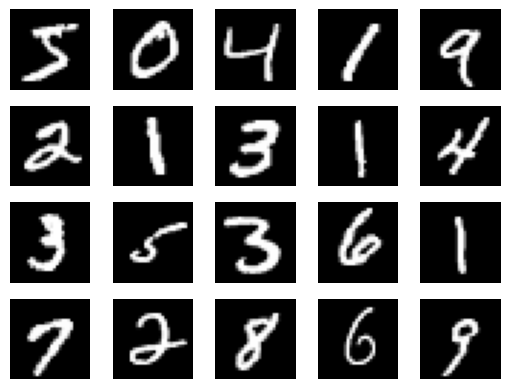

In [40]:
if __name__ == '__main__':
    train_x, train_y, test_x, test_y = get_MNIST_data()
    print(train_x.shape)
    print(test_x.shape)
    plot_images(train_x[0, :])
    plot_images(train_x[0:20, :])

(12665, 784)
(12665,)


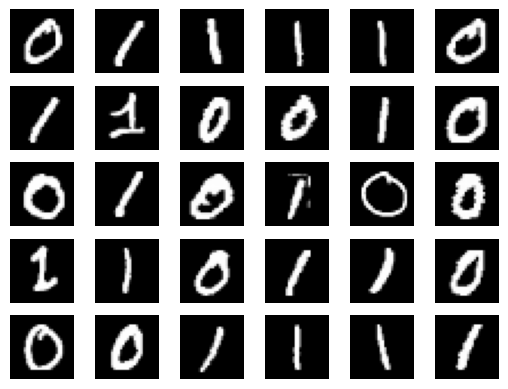

In [52]:
train_mask = (train_y == 0) | (train_y == 1)
test_mask = (test_y == 0) | (test_y == 1)

train_x_bin = train_x[train_mask]
train_y_bin = train_y[train_mask]

test_x_bin = test_x[test_mask]
test_y_bin = test_y[test_mask]

print(train_x_bin.shape)
print(train_y_bin.shape)

plot_images(train_x_bin[0:30, :])